# VGSOT Simulation – API Guide

This notebook focuses on the **real parameter entry points** used by the project:

1. **High-level case APIs** accept a `Config` object.
2. **Default values live in `configs.py` dataclasses**.
3. Users can either:
   - run with the default config,
   - inspect the default values,
   - override selected fields,
   - or drop down to low-level APIs for full control.

> Recommended workflow: start from a case API + default `Config`, then customize only the fields you need.

## 0. Common imports

In [1]:
from pathlib import Path
from pprint import pprint
from dataclasses import fields, is_dataclass

import matplotlib.pyplot as plt
import numpy as np
np.random.seed(100)

from vgsot_sim import (
    config_to_params,
    save_single_plot,
    save_grouped_timeseries_csv,
    save_three_panel_plot,
    save_two_panel_plot,
    ensure_result_dir,

    PhysicalConstantsConfig,

    TerminalVoltageControlConfig,
    SotOnlyConstantCurrentConfig,
    SotSwitchingNoVcmaConfig,
    SerSotNoVcmaThermalConfig,
    VcmaAssistedSwitchingIsotSweepConfig,
    VcmaAssistedSwitchingVmtjSweepConfig,
    OptimizedVgsotSwitchingConfig,
    SerOptimizedVgsotConfig,

    terminal_voltage_control,
    sot_only_constant_current,
    sot_switching_no_vcma,
    vcma_assisted_switching_isot_sweep,
    vcma_assisted_switching_vmtj_sweep,
    optimized_vgsot_switching,
    ser_sot_no_vcma_thermal,
    ser_optimized_vgsot,

    run_piecewise_direct_excitation,
    run_two_pulse_optimized,
)

OUT_DIR = ensure_result_dir("result_notebook")
print("Output directory:", OUT_DIR)

Output directory: result_notebook


## 1. How to expose default values from a Config

Every high-level case API uses a dataclass-style config.  
The easiest ways to inspect defaults are:

- print the config object,
- convert it to a dictionary with `config_to_params(...)`,
- or iterate over dataclass fields.

In [2]:
from vgsot_sim import SerSotNoVcmaThermalConfig

cfg = SerSotNoVcmaThermalConfig()
print(cfg)

SerSotNoVcmaThermalConfig(i_sot_list=(-0.0008, -0.0007, -0.00075, -0.0006, -0.0005, -0.0004, -0.0003, -0.0002), trials=200, sim_start_step=1, sim_mid1_step=5000, sim_end_step=10000, pap=1, non=1, v_mtj=0.0, vnv=0, r_sot_fl_dl=0.0, target_mz=1.0, failure_tol=0.1, constants=PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=2.4e-07, w=2e-07, d=4.3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=8e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.19, RA=3.6e-11))


## 2. Default config vs custom config

### 2.1 Run with default config

In [3]:
from vgsot_sim import sot_only_constant_current

res_default = sot_only_constant_current()
print(type(res_default).__name__)
print("time points:", res_default.time_s.shape)

direct_excitation: 100%|████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 23754.72it/s]

SimResult
time points: (5001,)


### 2.2 Override only the fields you care about

The rest stay at their defaults.

In [4]:
from vgsot_sim import SotOnlyConstantCurrentConfig

cfg_custom = SotOnlyConstantCurrentConfig(
    i_sot_stage1=-105e-6,
    sim_mid1_step=1800,
    sim_end_step=4500,
    pap=1,
)

print(cfg_custom)
res_custom = sot_only_constant_current(cfg_custom)
print("custom result points:", res_custom.time_s.shape)

SotOnlyConstantCurrentConfig(sim_start_step=1, sim_mid1_step=1800, sim_end_step=4500, pap=1, i_sot_stage1=-0.000105, i_sot_stage2=0.0, v_mtj_stage1=0.0, v_mtj_stage2=0.0, vnv=1, non=1, r_sot_fl_dl=0.83, tick_spacing_s=5e-10, constants=PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=2.4e-07, w=2e-07, d=4.3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=8e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.19, RA=3.6e-11))


direct_excitation: 100%|████████████████████████████████████████████████████████| 4500/4500 [00:00<00:00, 34548.76it/s]

custom result points: (4501,)


### 2.3 Customizing Physical Constants
the physical constants are exposed through `PhysicalConstantsConfig`, so users can:

- inspect all available constants,
- understand what each constant means,
- override only the constants they want to change,
- and pass the customized constants into a simulation config.

This is useful when you want to study material variation, geometry scaling, temperature dependence, VCMA strength, or numerical time-step sensitivity.

In [5]:
from vgsot_sim import PhysicalConstantsConfig


# Default constants (reference)
const_default = PhysicalConstantsConfig()
print("const_default\n", const_default)


# Fully customized constants (all parameters exposed)
const_modified = PhysicalConstantsConfig(
    # ===== Elementary constants =====
    u0=12.56637e-7,     # Vacuum permeability (H/m)
    e=1.6e-19,          # Elementary charge (C)
    h_bar=1.054e-34,    # Reduced Planck constant (J·s)
    uB=9.274e-24,       # Bohr magneton (J/T)
    kb=1.38e-23,        # Boltzmann constant (J/K)
    m=9.11e-31,         # Electron mass (kg)

    # ===== Geometry / electronic parameters =====
    # R_SOT = 776Ω, Area_SOT = 800 nm2
    l=220e-9,            # SOT channel length (m)
    w=200e-9,            # Device width (m)
    d=4.0e-9,            # SOT thickness (m)
    rho=278e-8,          # Resistivity (Ω·m)

    # ===== Magnetic / material parameters =====
    Ki=0.32e-3,         # Interfacial anisotropy energy density (J/m^2)
    Ms=0.625e6,         # Saturation magnetization (A/m)
    beta=60e-15,        # VCMA coefficient (J/V·m)
    tf=1.1e-9,          # Free-layer thickness (m)
    tox=1.4e-9,         # Tunnel barrier thickness (m)
    D=80e-9,            # MTJ diameter (m)
    T=300,              # Temperature (K)
    alpha=0.05,         # Gilbert damping (unitless)
    t_step=1e-12,       # Simulation time step (s)

    # ===== Switching / transport parameters =====
    Vh=0.5,             # TMR half-bias voltage (V)
    P=0.58,             # Spin polarization (unitless)
    theta_SH=0.25,      # Spin Hall angle (unitless)
    phi_bar=0.4,        # Barrier height (eV)
    TMR=1.19,           # TMR ratio (unitless)
    RA=36e-12,          # Resistance-area product (Ω·m^2)
)

print("const_modified\n", const_modified)

const_default
 PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=2.4e-07, w=2e-07, d=4.3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=8e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.19, RA=3.6e-11)
const_modified
 PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=2.2e-07, w=2e-07, d=4e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=8e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.19, RA=3.6e-11)


## 3. Recommended API layers

### High-level APIs
Use these for most experiments:

- `terminal_voltage_control(cfg)`
- `sot_only_constant_current(cfg)`
- `sot_switching_no_vcma(cfg)`
- `vcma_assisted_switching_isot_sweep(cfg)`
- `vcma_assisted_switching_vmtj_sweep(cfg)`
- `optimized_vgsot_switching(cfg)`
- `ser_sot_no_vcma_thermal(cfg)`
- `ser_optimized_vgsot(cfg)`

### Low-level APIs
Use these only when you want to manually define pulse timing and excitation:

- `run_piecewise_direct_excitation(...)`
- `run_two_pulse_optimized(...)`

## 4. Example: baseline SOT-only switching

This is the simplest pattern users should copy:

1. instantiate a config,
2. inspect it,
3. modify selected fields,
4. run the case.

SotOnlyConstantCurrentConfig(sim_start_step=1, sim_mid1_step=1000, sim_end_step=3000, pap=1, i_sot_stage1=-0.000620433, i_sot_stage2=0.0, v_mtj_stage1=0.0, v_mtj_stage2=0.0, vnv=1, non=1, r_sot_fl_dl=0.83, tick_spacing_s=5e-10, constants=PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=2.2e-07, w=2e-07, d=4e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=8e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.19, RA=3.6e-11))


direct_excitation: 100%|████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 23981.52it/s]


Saved: result_notebook\sot_only_constant_current.png


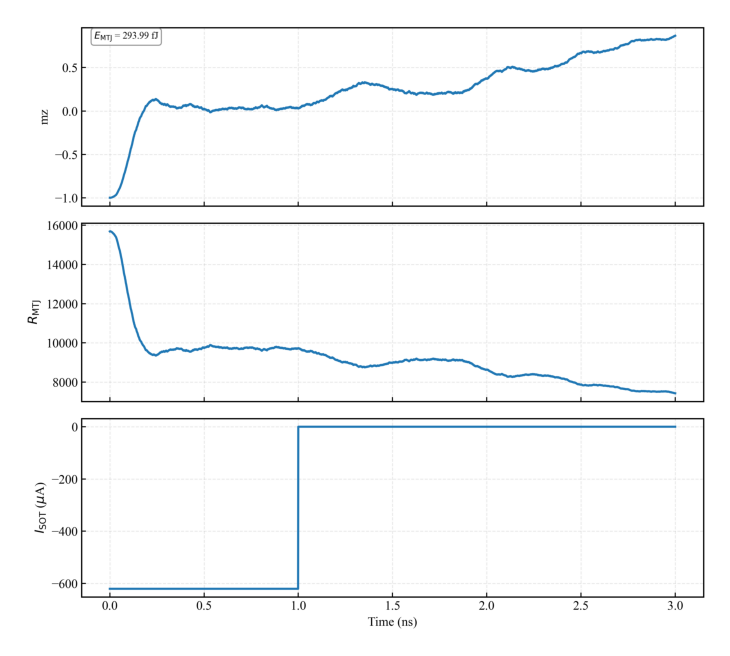

In [6]:
from vgsot_sim import (
    SotOnlyConstantCurrentConfig,
    sot_only_constant_current,
    save_three_panel_plot,
)

cfg = SotOnlyConstantCurrentConfig(
    sim_mid1_step=1000,
    sim_end_step=3000,
    i_sot_stage1=-620.433e-6,
    constants=const_modified,
)
print(cfg)
res = sot_only_constant_current(cfg)

baseline_path = OUT_DIR / "sot_only_constant_current.png"
save_three_panel_plot(
    baseline_path,
    res.time_s,
    {"mz": res.mz},
    {r"$R_{\mathrm{MTJ}}$": res.r_mtj},
    {r"$I_{\mathrm{SOT}}$": res.i_sot * 1e6},
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=r"$I_{\mathrm{SOT}}$ ($\mu$A)",
    tick_spacing_s=cfg.tick_spacing_s,
    x_is_time=True,
    switch_energy_j=res.switch_energy_j,
)

print("Saved:", baseline_path)
plt.figure(figsize=(7, 4))
img = plt.imread(baseline_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 5. Example: SOT switching without VCMA using a high-level Config

How to run an `I_SOT` sweep through a high-level config, and how to save the simulation results to local files, just like the CLI does.

The result object contains grouped curves for:
- `mz`
- `R_MTJ`
- pulse waveform (`I_SOT`)


In [7]:
from vgsot_sim import (
    SotSwitchingNoVcmaConfig,
    sot_switching_no_vcma,
    save_grouped_timeseries_csv
)

cfg = SotSwitchingNoVcmaConfig(
    v_mtj=0.0,
    i_sot_list=[-800e-6, -700e-6, -750e-6, -600e-6, -500e-6, -400e-6, -300e-6, -200e-6],
    sim_mid1_step=5000,
    sim_end_step=10000,
    tick_spacing_s=1e-09,
    constants=const_modified,
)

print(cfg)
res = sot_switching_no_vcma(cfg)
print("Available sweep labels:")
for k in res.mz_curves.keys():
    print(" ", k)

SotSwitchingNoVcmaConfig(i_sot_list=[-0.0008, -0.0007, -0.00075, -0.0006, -0.0005, -0.0004, -0.0003, -0.0002], sim_start_step=1, sim_mid1_step=5000, sim_end_step=10000, pap=1, non=1, v_mtj=0.0, i_sot_relax=0.0, vnv=0, r_sot_fl_dl=0.83, tick_spacing_s=1e-09, constants=PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=2.2e-07, w=2e-07, d=4e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=8e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.19, RA=3.6e-11))


direct_excitation: 100%|██████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 31904.00it/s]

Available sweep labels:
  I_SOT=-800.0uA
  I_SOT=-700.0uA
  I_SOT=-750.0uA
  I_SOT=-600.0uA
  I_SOT=-500.0uA
  I_SOT=-400.0uA
  I_SOT=-300.0uA
  I_SOT=-200.0uA


In [8]:
# Save results locally (same pattern as in cli.py)
from vgsot_sim import save_grouped_timeseries_csv


sot_no_vcma_csv_path = OUT_DIR / "sot_switching_no_vcma.csv"
sot_no_vcma_png_path = OUT_DIR / "sot_switching_no_vcma.png"

save_grouped_timeseries_csv(
    sot_no_vcma_csv_path,
    res.time_s,
    {
        "mz": res.mz_curves,
        "r_mtj": res.r_mtj_curves,
        "pulse": res.pulse_curves,
    },
)

Saved CSV: result_notebook\sot_switching_no_vcma.csv
Saved figure: result_notebook\sot_switching_no_vcma.png


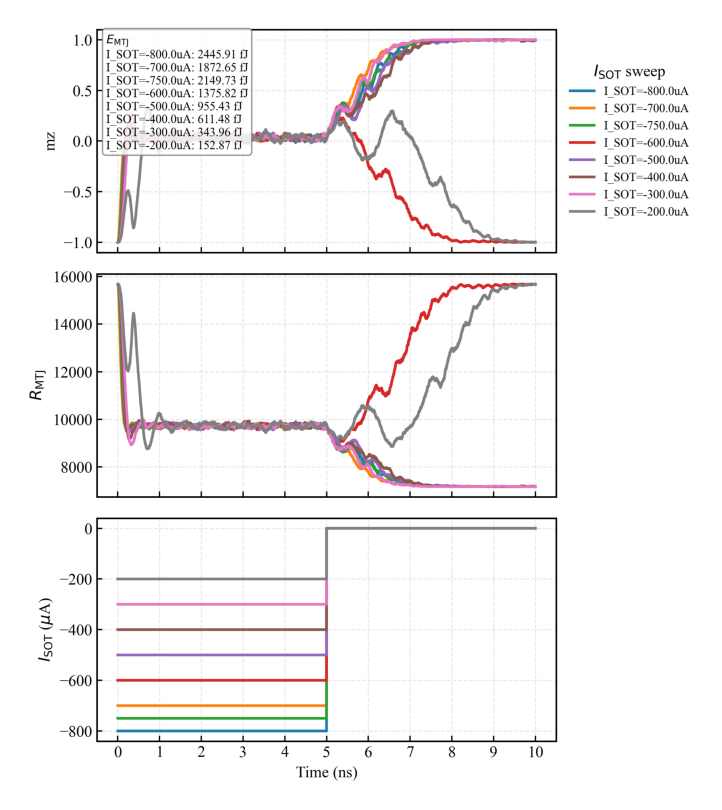

In [9]:
# plot
save_three_panel_plot(
    sot_no_vcma_png_path,
    res.time_s,
    res.mz_curves,
    res.r_mtj_curves,
    res.pulse_curves,
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=res.pulse_ylabel,
    tick_spacing_s=cfg.tick_spacing_s,
    legend_title=r"$I_{\mathrm{SOT}}$ sweep",
    x_is_time=True,
    switch_energy_j=res.switch_energy_j,
)

print("Saved CSV:", sot_no_vcma_csv_path)
print("Saved figure:", sot_no_vcma_png_path)

plt.figure(figsize=(8, 5))
img = plt.imread(sot_no_vcma_png_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 6. Example: SER simulation and how to customize reliability settings

This example highlights a very important documentation point:

- `trials` controls Monte Carlo sample count
- `target_mz` and `failure_tol` define the failure criterion
- `i_sot_list` defines the x-axis sweep

In [10]:
print(SerSotNoVcmaThermalConfig())

SerSotNoVcmaThermalConfig(i_sot_list=(-0.0008, -0.0007, -0.00075, -0.0006, -0.0005, -0.0004, -0.0003, -0.0002), trials=200, sim_start_step=1, sim_mid1_step=5000, sim_end_step=10000, pap=1, non=1, v_mtj=0.0, vnv=0, r_sot_fl_dl=0.0, target_mz=1.0, failure_tol=0.1, constants=PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=2.4e-07, w=2e-07, d=4.3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=8e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.19, RA=3.6e-11))


In [22]:
cfg = SerSotNoVcmaThermalConfig(
    i_sot_list=[-470e-6, -460e-6, -455e-6, -450e-6, -447e-6, -445e-6, -442e-6, -440e-6, -435e-6, -430e-6, -420e-6],
    sim_mid1_step=5000,
    sim_end_step=10000,
    trials=100,
    failure_tol=10e-2,
    target_mz=1,
    constants=const_modified,
)

res = ser_sot_no_vcma_thermal(cfg)
print("x:", res.x)
print("SER:", res.ser)

MC isot=-4.200e-04A: 100%|███████████████████████████████████████████████████████████| 100/100 [00:30<00:00,  3.29it/s]

x: [-0.00047  -0.00046  -0.000455 -0.00045  -0.000447 -0.000445 -0.000442
 -0.00044  -0.000435 -0.00043  -0.00042 ]
SER: [0.19 0.21 0.29 0.55 0.59 0.75 0.73 0.89 0.94 0.98 1.  ]


Saved: result_notebook\ser_sot_no_vcma_thermal.png


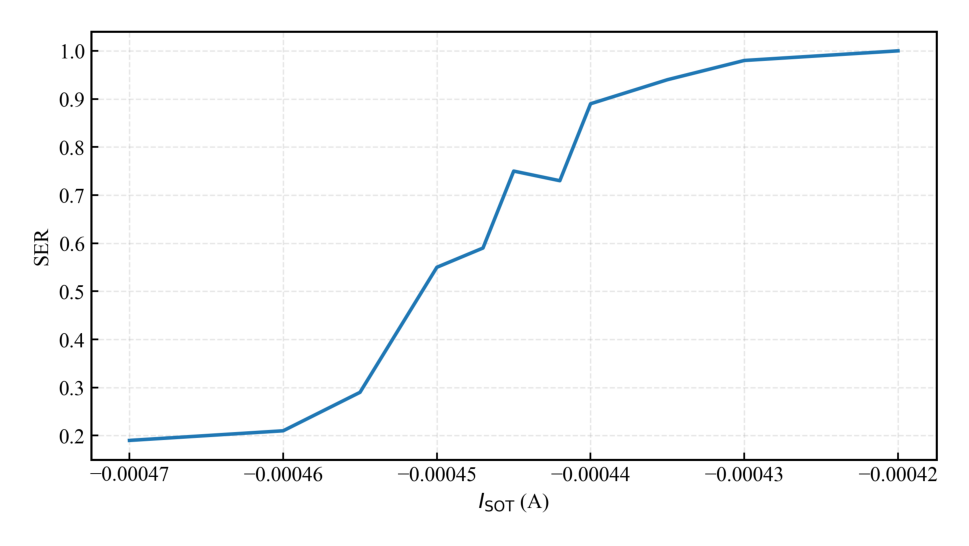

In [23]:
ser_path = OUT_DIR / "ser_sot_no_vcma_thermal.png"

save_single_plot(
    ser_path,
    res.x,
    {"SER": res.ser},
    xlabel=res.x_label,
    ylabel="SER",
    x_is_time=False,
)

print("Saved:", ser_path)
plt.figure(figsize=(6, 4))
img = plt.imread(ser_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 7. Low-level API example: full manual pulse definition

Use a low-level API only when you need direct control over stage-by-stage excitation.

This is the correct place to specify raw values such as:

- pulse timing,
- stage voltages/currents,
- STT/SOT enable flags,
- thermal noise and VCMA switches.

In [14]:
res = run_piecewise_direct_excitation(
    sim_start_step=1,
    sim_mid1_step=1500,
    sim_mid2_step=3000,
    sim_end_step=5000,
    pap=1,

    v_mtj_stage1=1.2,
    v_mtj_stage2=-0.8,
    v_mtj_stage3=0.0,

    i_sot_stage1=-90e-6,
    i_sot_stage2=0.0,
    i_sot_stage3=0.0,

    estt_stage1=0,
    esot_stage1=1,
    estt_stage2=0,
    esot_stage2=1,
    estt_stage3=0,
    esot_stage3=1,

    vnv=1,
    non=1,
    r_sot_fl_dl=0.0,
)

print(type(res).__name__)
print("time shape:", res.time_s.shape)

direct_excitation: 100%|████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 37451.88it/s]

SimResult
time shape: (5001,)


In [15]:
res = run_two_pulse_optimized(
    t1_s=1.5e-9,
    t2_s=1.5e-9,
    v_mtj_1=1.4937,
    v_mtj_2=-1.0,
    i_sot_1=-100e-6,
    i_sot_2=0.0,
    sim_total_time_s=25e-9,
    pap=1,
    non=1,
    vnv=1,
    r_sot_fl_dl=0.0,
)

print(type(res).__name__)
print("time shape:", res.time_s.shape)
print("energy (fJ):", res.switch_energy_j * 1e15)

direct_excitation: 100%|██████████████████████████████████████████████████████| 25000/25000 [00:00<00:00, 33585.13it/s]

SimResult
time shape: (25001,)
energy (fJ): 653.7648302046364


## 8. Quick reference: how should users choose an API?

### Choose a high-level case API when:
- you want to reproduce a built-in experiment,
- you want sensible defaults,
- you want to customize only a few knobs.

### Choose a low-level API when:
- you need exact pulse-by-pulse control,
- you want to define stages manually,
- you are building a new experiment not covered by existing case wrappers.

## 9. Quick reference: common documentation patterns you should keep

When adding or updating docs for any new case, always include these four blocks:

1. **Default config**  
   Show `print(cfg)` or `pprint(config_to_params(cfg))`

2. **Minimal runnable example**  
   Show the default call

3. **Custom config example**  
   Override 2–4 representative fields

4. **When to use this API**  
   Explain whether it is a high-level case API or a low-level kernel

## 10. Summary

The most important thing for users to understand is:

- **Config classes are the main parameter interface**
- **Default values are defined in `configs.py`**
- **Use `config_to_params(cfg)` to expose defaults clearly**
- **Customize configs by overriding only selected fields**
- **Drop down to low-level APIs only when you need full manual control**